In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [2]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [3]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

[ Info: Precompiling RVSDDP [7c8f0945-522d-4538-8433-0d76605ce121] (cache misses: wrong dep version loaded (4))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (20))
[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] (cache misses: wrong dep version loaded (14))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (10))
[ Info: Precompiling Gurobi [2e9cd046-0924-5485-92f1-d5272153d98b] (cache misses: wrong dep version loaded (20))


Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


[ Info: Precompiling Distributions [31c24e10-a181-5473-b8eb-7969acd0382f] (cache misses: wrong dep version loaded (16))
[ Info: Precompiling DistributionsTestExt [ffbe0ea5-a612-5ff7-aaf5-cac02eef3019] (cache misses: wrong dep version loaded (16))


Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#1 (generic function with 1 method)

In [11]:
folder_list = Dict("RV-SDDP" => "shift_update_random_forward_0_parallel_1", "Cyclic SDDP" => "no_shift_0_parallel_1", "Finite SDDP" => "no_shift_finite_parallel_1")
# folder_list = Dict("RV-SDDP" => "shift_update_random_forward_0_parallel_1", "Cyclic SDDP" => "no_shift_0_parallel_1")

# folder_list = Dict("Finite SDDP" => "no_shift_finite_parallel_1")

# folder_list = Dict("Periodic SDDP" => "no_shift_0_parallel_1", "RV-SDDP" => "shift_update_random_forward_0_parallel_1")
#, "Finite SDDP" => "no_shift_finite_parallel_1")

Dict{String, String} with 3 entries:
  "Cyclic SDDP" => "no_shift_0_parallel_1"
  "RV-SDDP"     => "shift_update_random_forward_0_parallel_1"
  "Finite SDDP" => "no_shift_finite_parallel_1"

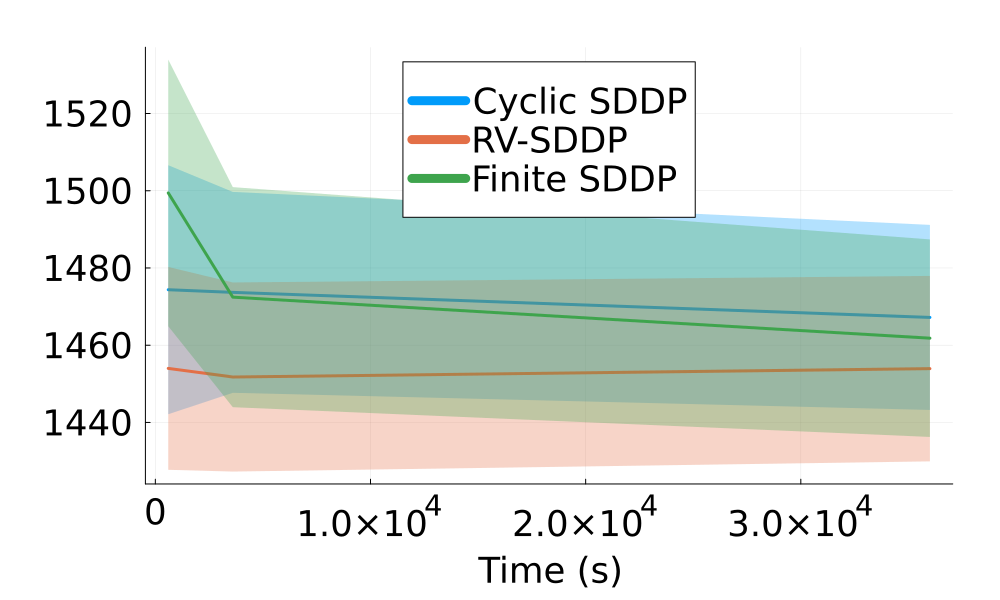

In [13]:
results = Dict()
seed_list = 1:5
time_max = 36000
parallel = 1
# time_list_value = 125:140
time_list_oos = [600,  3600, 36000]
# time_list_oos = [300, 600, 900, 1800, 3600]
# shift_list = [RVSDDP.no_shift]
discount_factor=0.995
period = 12
N=500
TimeHorizon = 12*Int(ceil(log(0.001)/(12*log(discount_factor))))
time_list_value = 300:300:36000
for seed in seed_list
      for (label,folder) in folder_list
            if label == "Finite SDDP"
                  TimeHorizon = min(12*Int(ceil(log(0.001)/(12*log(discount_factor)))), 120)
                  # TimeHorizon = 120
            else
                  TimeHorizon = 12*Int(ceil(log(0.001)/(12*log(discount_factor))))
            end
            folder = "results_msppy/$(folder)/$(discount_factor)/seed_$(seed)_time_$(time_max)"
            if isdir("$(folder)/oos")
                  oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_5_$(time)_$(TimeHorizon).csv"), DataFrame) for time in time_list_oos]
                  oos_mean = [mean(oos_df[i][1:N, :oos_horizon])/1000 for i in 1:length(oos_df)]
                  oos_std = [std(oos_df[i][1:N, :oos_horizon])/1000 for i in 1:length(oos_df)]
            else
                  oos_mean = [0.0 for _ in time_list_oos]
                  oos_std = [0.0 for _ in time_list_oos]
            end
            # oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_10_$(time)_$(TimeHorizon).csv"), DataFrame) for time in time_list_oos]
            filename = joinpath(folder, "active_cuts.csv")
            if isfile(filename)
                  active_cuts_df = CSV.read(filename, DataFrame)
                  active_cuts = [sum(active_cuts_df[active_cuts_df[:, :time] .== t, :num_active_cuts])/length(active_cuts_df[active_cuts_df[:, :time] .== t, :num_active_cuts]) for t in time_list_oos]
                  df_cuts = CSV.read("$(folder)/cuts.csv", DataFrame)
                  nb_cuts = [sum([1 for row in eachrow(df_cuts) if row.time <= t])/length(active_cuts_df[active_cuts_df[:, :time] .== t, :num_active_cuts]) for t in time_list_oos]
            else
                  active_cuts = [0.0 for _ in time_list_oos]
                  nb_cuts = [0.0 for _ in time_list_oos]
            end
            results[(seed, label)] = (oos_mean, oos_std, active_cuts, nb_cuts)
      end
end


results_mean = Dict()
for label in keys(folder_list)
    all_oos_mean = [results[(seed, label)][1] for seed in seed_list]
    all_oos_std = [results[(seed, label)][2] for seed in seed_list]
    all_active_cuts = [results[(seed, label)][3] for seed in seed_list]
    all_nb_cuts = [results[(seed, label)][4] for seed in seed_list]
    
    oos_mean_matrix = hcat(all_oos_mean...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    oos_std_matrix = hcat(all_oos_std...)  # 10 x 10 matrix (10 iterations x 10 seeds)

    oos_mean = mean(oos_mean_matrix, dims=2)[:]
    oos_std = mean(oos_std_matrix, dims=2)[:]

    active_cuts_matrix = hcat(all_active_cuts...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    active_cuts_mean = mean(active_cuts_matrix, dims=2)[:]

    nb_cuts_matrix = hcat(all_nb_cuts...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    nb_cuts_mean = mean(nb_cuts_matrix, dims=2)[:]

    results_mean[label] = (oos_mean, oos_std, active_cuts_mean, nb_cuts_mean)
end

tcrit = quantile(TDist(N-1), 0.975)

fontsize = 24
p=plot(xlabel="Time (s)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 600), margin=10Plots.mm, legend=:top)
color=1
for (label, _) in folder_list
      # lower_bound = results_mean[label][5]+results_mean[label][6]
      # if label == "RV-SDDP"
      #       lower_bound = results_mean[label][5]+results_mean[label][6]
      # end
      oos_mean = results_mean[label][1]
      oos_mean_up = results_mean[label][1] + tcrit * results_mean[label][2] / sqrt(N)
      oos_mean_down = results_mean[label][1] - tcrit * results_mean[label][2] / sqrt(N)

      # plot!(time_list_value, lower_bound, label=label, linewidth=3, color = color)
      plot!(time_list_oos, oos_mean,label=label, ribbon=(oos_mean - oos_mean_down, oos_mean_up - oos_mean), linewidth=3, fillalpha=0.3, color = color)
      # plot!(time_list_oos, results_mean[label][9], label=label, linewidth=3, fillalpha=0.0, color = color)
      color += 1
end
p
# savefig(p, "results_msppy/cost_$discount_factor.png")
# savefig(p, "results_msppy/active_cuts_$discount_factor.png")

In [70]:
function latex_escape(s::AbstractString)
    return replace(s, "_" => "\\_")
end

function fmt_int(x)
    return string(round(Int, x))
end

function write_overleaf_table(
    results_mean,
    time_list_oos;
    discount_factor = 0.99,
    filename = "results_table_beta_$(discount_factor).txt",
    caption = "Comparison of methods.",
    label = "tab:comparison_beta"
)
    open(filename, "w") do io
        println(io, "\\begin{table}[ht]")
        println(io, "\\centering")
        println(io, "\\footnotesize")
        println(io, "\\setlength{\\tabcolsep}{4pt}")
        println(io, "\\caption{$caption Costs are reported as mean \$\\pm\$ standard deviation. A/T denotes the number of active cuts over total cuts (on average per stage).}")
        println(io, "\\label{$label}")
        println(io, "\\begin{tabular}{lcc|cc|cc}")
        println(io, "\\toprule")

        println(io,
            "& \\multicolumn{2}{c|}{$(time_list_oos[1]) s} " *
            "& \\multicolumn{2}{c|}{$(time_list_oos[2]) s} " *
            "& \\multicolumn{2}{c}{$(time_list_oos[3]) s} \\\\"
        )

        println(io, "\\cmidrule(r){2-3}")
        println(io, "\\cmidrule(r){4-5}")
        println(io, "\\cmidrule(l){6-7}")

        println(io,
            "Method " *
            "& Cost & Cuts (A/T) " *
            "& Cost & Cuts (A/T) " *
            "& Cost & Cuts (A/T) \\\\"
        )

        println(io, "\\midrule")

        for label_method in keys(results_mean)
            oos_mean = results_mean[label_method][1]
            oos_std = results_mean[label_method][2]
            active_cuts_mean = results_mean[label_method][3]
            total_cuts_mean = results_mean[label_method][4]

            method_name = latex_escape(string(label_method))

            row = method_name

            for i in 1:3
                cost = fmt_int(oos_mean[i])
                std = fmt_int(Int(round(tcrit * oos_std[i]/ sqrt(N))))
                active = fmt_int(active_cuts_mean[i])
                total = fmt_int(total_cuts_mean[i])

                row *= " & \$$(cost) \\pm $(std)\$ & $(active) / $(total)"
            end

            row *= " \\\\"
            println(io, row)
        end

        println(io, "\\bottomrule")
        println(io, "\\end{tabular}")
        println(io, "\\end{table}")
    end
end

write_overleaf_table (generic function with 1 method)

In [77]:
write_overleaf_table(
    results_mean,
    time_list_oos;
    discount_factor = discount_factor,
    filename = "results_msppy/table_beta_$(discount_factor).txt",
    caption = "Comparison of methods for \$\\beta=$(discount_factor)\$.",
    label = "tab:comparison_beta_$(replace(string(discount_factor), "." => ""))"
)

In [ ]:
iter_time = Dict()
seed_list = 1:5
parallel = 1
folder_list = Dict("SDDP" => "no_shift_finite_parallel_1")
discount_factor=0.995
for seed in seed_list
    for (label, folder) in folder_list
        folder = "results_msppy/$(folder)/$(discount_factor)/seed_$(seed)_time_$(time_max)"
        df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
        approx_values = df_approx_values[1:end, :approx_value]
        # for iter in 1:length(approx_values)
        #     iter_time[(seed, shift)] = 0.0
        # end
        iter_time[(seed, label)] = [0.0 for _ in 1:length(approx_values)]
        df_cuts = CSV.read("$(folder)/cuts.csv", DataFrame)
        for row in eachrow(df_cuts)
            if row.iteration >=1
                iter_time[(seed, label)][row.iteration] = max(iter_time[(seed, label)][row.iteration], row.time)
            end
        end
        approx_value_data = []
        for row in eachrow(df_approx_values)
            push!(approx_value_data, Dict(
                :iteration => row.iteration,
                :approx_value => row.approx_value,
                :time => iter_time[(seed, label)][row.iteration]
            ))
        end
        CSV.write(joinpath(folder, "approx_values_with_time.csv"), DataFrame(approx_value_data))
    end
end